In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Define the path to your archive folder in Google Drive
archive_path = '/content/drive/MyDrive/archive'

# Check if the directory exists
if os.path.exists(archive_path):
    print(f"Listing contents of: {archive_path}")
    # List all files and directories in the archive folder
    for item in os.listdir(archive_path):
        print(item)
else:
    print(f"The directory '{archive_path}' does not exist. Please make sure the path is correct and your Drive is mounted.")

Listing contents of: /content/drive/MyDrive/archive
20_Fingers
Adamski
ABBA
Adiemus
Adriano_Celentano
10cc
98_Degrees
101_Strings
.DS_Store
AC_DC
Adamo
10,000_Maniacs
Acoustic_Alchemy
1910_Fruitgum_Company
2_Brothers_on_the_4th_Floor
Ace_Frehley
Ace
4_Non_Blondes
Adam_and_Eve
ABC
2_Unlimited
883
2Boys
311
.gitattributes
3T
Ace_of_Base
808_State
Aaliyah
2_the_Core
702
911
.38 Special
Aaron_Neville
Albert_West
Allan_Theo
Air_Supply
Alliage
Al_Green
Alanis_Morissette
Allan_Sherman
Alice_in_Chains
Al_Hirt
Alain_Chamfort
Alive
Alison_Moyet
Adventures_of_Stevie_V
Alice_Cooper
Alexia
AL_Bano
Alannah_Myles
ANKA_PAUL
Alain_Barriere
All_Saints
Alexandra
Al_Wilson
Aerosmith
Alexander_O_Neal
Alberti
A_Teens
ARMSTRONG_LOUIS
Alain_Souchon
Alan_Parsons
Alabama
All-4-One
Alexander_Peter
Alien_Ant_Farm
Alpenrebellen
Al_Jarreau
Al_Martino
Alice
Alizee
Allure
Allen_Toussaint
Albert_Hammond
Alain_Bashung
Alan_Jackson
A_Taste_of_Honey
Alberto_Fortis
Al_Stewart
Al_Jolson
Alma_Cogan


In [ ]:
import os

def find_midi_files(root_dir):
    midi_files = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.lower().endswith(('.mid', '.midi')):
                midi_files.append(os.path.join(dirpath, filename))
    return midi_files

archive_path = '/content/drive/MyDrive/archive'

print(f"Searching for MIDI files in: {archive_path}")
all_midi_files = find_midi_files(archive_path)

if all_midi_files:
    print(f"Found {len(all_midi_files)} MIDI files:")
    for midi_file in all_midi_files:
        print(midi_file)

    # Check for specific artists as requested
    print("\nChecking for 'Alice in Chains' and other artists:")
    found_artists_midi = {}
    for midi_file in all_midi_files:
        # Extract artist name from the path (assuming the folder name is the artist)
        artist = os.path.basename(os.path.dirname(midi_file))
        if artist not in found_artists_midi:
            found_artists_midi[artist] = []
        found_artists_midi[artist].append(midi_file)

    for artist, files in found_artists_midi.items():
        print(f"  Artist: {artist} - {len(files)} MIDI files")

    if 'Alice_in_Chains' in found_artists_midi:
        print("\nFound 'Alice in Chains' MIDI files!")
        for f in found_artists_midi['Alice_in_Chains']:
            print(f"  - {f}")
    else:
        print("\n'Alice in Chains' MIDI files not found directly in a folder named 'Alice_in_Chains'.")

else:
    print("No MIDI files found in the specified archive path.")


Searching for MIDI files in: /content/drive/MyDrive/archive
Found 697 MIDI files:
/content/drive/MyDrive/archive/20_Fingers/Lick_It.mid
/content/drive/MyDrive/archive/20_Fingers/Short_Dick_Man.mid
/content/drive/MyDrive/archive/Adamski/Love_and_Life.mid
/content/drive/MyDrive/archive/ABBA/Fernando.2.mid
/content/drive/MyDrive/archive/ABBA/Fernando.10.mid
/content/drive/MyDrive/archive/ABBA/Dancing_Queen.mid
/content/drive/MyDrive/archive/ABBA/Fernando.1.mid
/content/drive/MyDrive/archive/ABBA/Does_Your_Mother_Know.1.mid
/content/drive/MyDrive/archive/ABBA/Dancing_Queen.7.mid
/content/drive/MyDrive/archive/ABBA/Dancing_Queen.2.mid
/content/drive/MyDrive/archive/ABBA/Does_Your_Mother_Know.4.mid
/content/drive/MyDrive/archive/ABBA/Dancing_Queen.4.mid
/content/drive/MyDrive/archive/ABBA/Dancing_Queen.5.mid
/content/drive/MyDrive/archive/ABBA/Dancing_Queen.11.mid
/content/drive/MyDrive/archive/ABBA/Dancing_Queen.1.mid
/content/drive/MyDrive/archive/ABBA/Fernando.11.mid
/content/drive/MyDriv

In [ ]:
!pip install music21
import music21

In [ ]:
import os
import numpy as np
import random
from music21 import converter, key, note, stream, interval, chord
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- 1. MIDI Search Logic ---
archive_path = '/content/drive/MyDrive/archive'
def find_midi_files(root_dir):
    midi_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.lower().endswith(('.mid', '.midi')):
                midi_files.append(os.path.join(dirpath, filename))
    return midi_files

all_midi_files = find_midi_files(archive_path)
found_artists_midi = {}
for midi_file in all_midi_files:
    artist = os.path.basename(os.path.dirname(midi_file))
    if artist not in found_artists_midi:
        found_artists_midi[artist] = []
    found_artists_midi[artist].append(midi_file)

# --- 2. Train/Test Split (Artist-based) ---
all_artists = list(found_artists_midi.keys())
train_artists = []
test_artists = []

if 'Alice_in_Chains' in all_artists:
    train_artists.append('Alice_in_Chains')
    remaining_artists = [a for a in all_artists if a != 'Alice_in_Chains']
else:
    remaining_artists = all_artists

random.shuffle(remaining_artists)
split_idx = int(len(remaining_artists) * 0.8)
train_artists.extend(remaining_artists[:split_idx])
test_artists.extend(remaining_artists[split_idx:])

train_pool = []
for artist in train_artists:
    train_pool.extend(found_artists_midi[artist])

global test_midi_files
test_midi_files = []
for artist in test_artists:
    test_midi_files.extend(found_artists_midi[artist])

# SELECT EXACTLY 30 FILES FROM TRAIN POOL
if len(train_pool) >= 30:
    aic_files = found_artists_midi.get('Alice_in_Chains', [])
    num_aic = min(len(aic_files), 10)
    other_train = [f for f in train_pool if f not in aic_files]
    filtered_midi_files = random.sample(aic_files, num_aic) + random.sample(other_train, 30 - num_aic)
else:
    filtered_midi_files = train_pool

# --- 3. Processing ---
def midi_to_piano_roll(midi_file_path, start_note=36, end_note=95):
    try:
        score = converter.parse(midi_file_path)
        k = score.analyze('key')
        if k.mode == 'major' and k.tonic.name != 'C':
            score = score.transpose(interval.Interval(k.tonic, note.Note('C')))
        elif k.mode == 'minor' and k.tonic.name != 'A':
            score = score.transpose(interval.Interval(k.tonic, note.Note('A')))
        resolution = 4
        flat_score = score.flatten()
        piano_roll_length = int(flat_score.highestTime * resolution) + 1
        piano_roll = np.zeros((end_note - start_note + 1, piano_roll_length))
        for el in flat_score.notes:
            start = int(el.offset * resolution)
            end = int((el.offset + el.duration.quarterLength) * resolution)
            if isinstance(el, note.Note) and start_note <= el.pitch.midi <= end_note:
                piano_roll[el.pitch.midi - start_note, start:end] = 1
            elif isinstance(el, chord.Chord):
                for p in el.pitches:
                    if start_note <= p.midi <= end_note:
                        piano_roll[p.midi - start_note, start:end] = 1
        return piano_roll
    except:
        return None

print(f"Artists: {len(train_artists)} Train / {len(test_artists)} Test")
print(f"Processing EXACTLY {len(filtered_midi_files)} files from the TRAIN set...")

processed_piano_rolls = []
for i, path in enumerate(filtered_midi_files):
    artist_name = os.path.basename(os.path.dirname(path))
    print(f"[{i+1}/30] Processing: {artist_name} - {os.path.basename(path)}")
    pr = midi_to_piano_roll(path)
    if pr is not None and pr.shape[1] > 64:
        seq_len = 64
        for j in range(0, pr.shape[1] - seq_len, seq_len // 2):
            processed_piano_rolls.append(pr[:, j:j+seq_len].T)

data_tensor = torch.FloatTensor(np.array(processed_piano_rolls))
print(f"Preprocessing Complete. Training Samples: {data_tensor.shape}")

Artists: 64 Train / 16 Test
Processing EXACTLY 30 files from the TRAIN set...
[1/30] Processing: Alice_in_Chains - Dam_That_River.mid
[2/30] Processing: Alice_in_Chains - Angry_Chair.mid
[3/30] Processing: Alice_in_Chains - No_Excuses.3.mid
[4/30] Processing: Alice_in_Chains - Sludge_Factory.mid
[5/30] Processing: Alice_in_Chains - Dont_Follow.mid
[6/30] Processing: Alice_in_Chains - Brother.mid
[7/30] Processing: Alice_in_Chains - Nutshell.mid
[8/30] Processing: Alice_in_Chains - No_Excuses.mid
[9/30] Processing: Alice_in_Chains - Over_Now.1.mid
[10/30] Processing: Alice_in_Chains - What_the_Hell_Have_I.mid
[11/30] Processing: Al_Martino - Blue_Spanish_Eyes.1.mid
[12/30] Processing: 883 - Senza_averti_qui.1.mid
[13/30] Processing: Alabama - Born_Country.1.mid
[14/30] Processing: 2_Unlimited - The_Real_Thing.1.mid
[15/30] Processing: Adamo - Non_sei_tu_Si_jamais_.mid
[16/30] Processing: ABBA - Thank_You_for_the_Music.8.mid
[17/30] Processing: Alanis_Morissette - Heart_of_the_House.mid


Using device: cuda
Starting training with metrics tracking and KL Annealing...
Epoch 0, Beta: 0.000, Train Loss: 285.8402, Val Loss: 194.4952
Epoch 10, Beta: 0.050, Train Loss: 93.7102, Val Loss: 103.4332
Epoch 20, Beta: 0.100, Train Loss: 75.5298, Val Loss: 92.9023
Epoch 30, Beta: 0.100, Train Loss: 61.0569, Val Loss: 86.3950
Epoch 40, Beta: 0.100, Train Loss: 50.0015, Val Loss: 80.9718
Epoch 50, Beta: 0.100, Train Loss: 41.8529, Val Loss: 79.4167


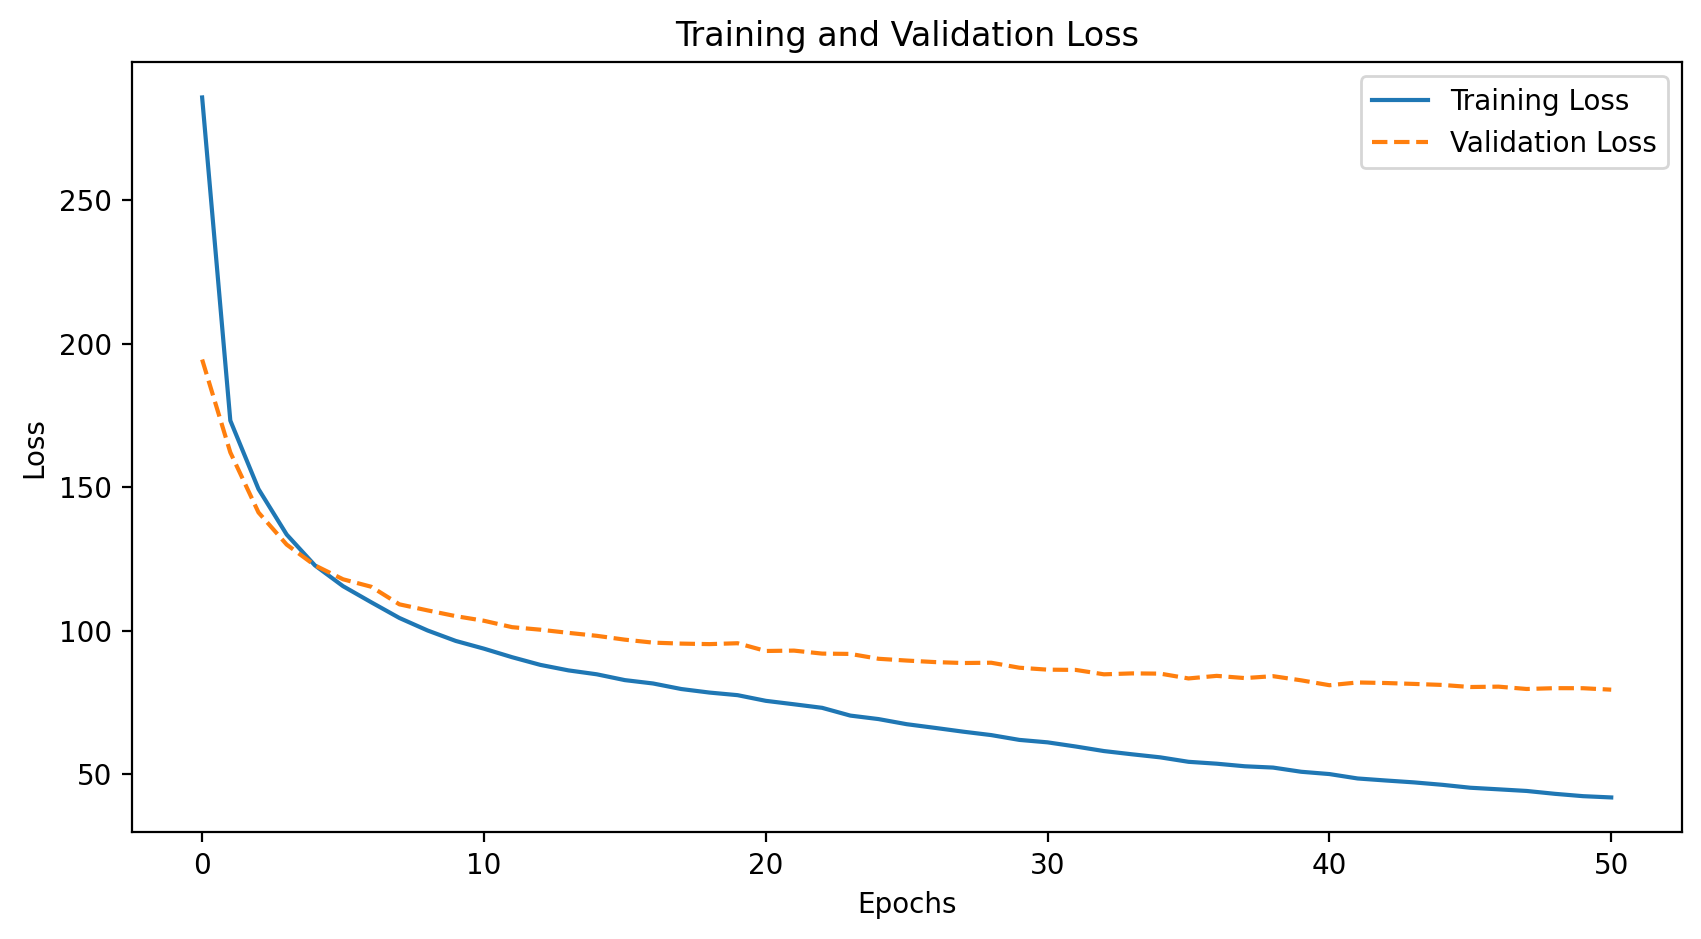

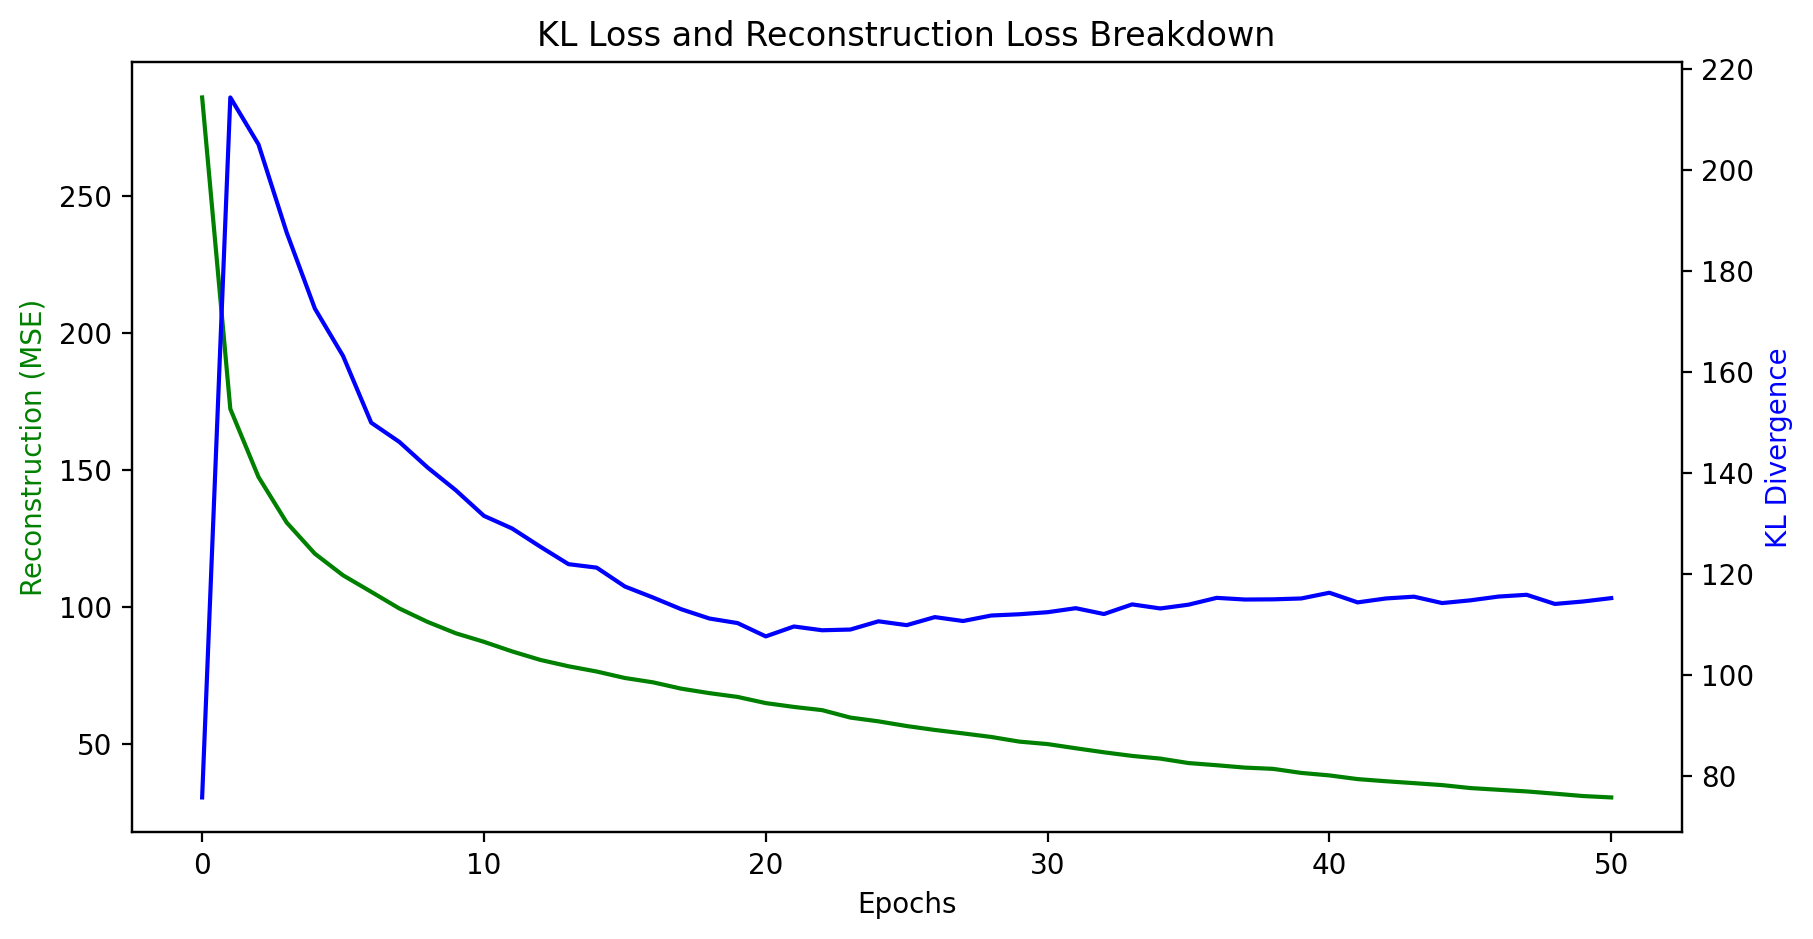

PDFs generated: task_loss_plot.pdf, kl_annealing_breakdown.pdf


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class VAE(nn.Module):
    def __init__(self, input_dim=3840, latent_dim=128):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x.view(-1, 3840))
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z).view(-1, 64, 60), mu, logvar

if 'data_tensor' in globals():
    model = VAE().to(device)
    optimizer = optim.Adam(model.parameters(), lr=5e-4)

    # Split data for validation
    val_size = int(0.1 * len(data_tensor))
    train_size = len(data_tensor) - val_size
    train_dataset, val_dataset = random_split(data_tensor, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)

    history = {"train_loss": [], "val_loss": [], "recon_loss": [], "kl_loss": []}
    total_epochs = 51
    warmup_epochs = 20

    print("Starting training with metrics tracking and KL Annealing...")
    for epoch in range(total_epochs):
        beta = min(0.1, 0.1 * (epoch / warmup_epochs)) if warmup_epochs > 0 else 0.1

        model.train()
        train_epoch_loss = 0
        epoch_recon = 0
        epoch_kl = 0

        for batch in train_loader:
            x = batch.to(device) if torch.is_tensor(batch) else batch[0].to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            MSE = nn.functional.mse_loss(recon, x, reduction='sum')
            KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = MSE + beta * KLD
            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()
            epoch_recon += MSE.item()
            epoch_kl += KLD.item()

        # Validation
        model.eval()
        val_epoch_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch.to(device) if torch.is_tensor(batch) else batch[0].to(device)
                recon, mu, logvar = model(x)
                MSE = nn.functional.mse_loss(recon, x, reduction='sum')
                KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                val_epoch_loss += (MSE + beta * KLD).item()

        history["train_loss"].append(train_epoch_loss / len(train_dataset))
        history["val_loss"].append(val_epoch_loss / len(val_dataset))
        history["recon_loss"].append(epoch_recon / len(train_dataset))
        history["kl_loss"].append(epoch_kl / len(train_dataset))

        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Beta: {beta:.3f}, Train Loss: {history["train_loss"][-1]:.4f}, Val Loss: {history["val_loss"][-1]:.4f}')

    # --- Plotting ---
    # Plot 1: Shared Axes Train/Val
    plt.figure(figsize=(10, 5))
    plt.plot(history["train_loss"], label='Training Loss', linestyle='-')
    plt.plot(history["val_loss"], label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('task_loss_plot.pdf')
    plt.show()

    # Plot 2: Recon vs KL breakdown
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.plot(history["recon_loss"], 'g-', label='Reconstruction Loss')
    ax2.plot(history["kl_loss"], 'b-', label='KL Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Reconstruction (MSE)', color='g')
    ax2.set_ylabel('KL Divergence', color='b')
    plt.title('KL Loss and Reconstruction Loss Breakdown')
    plt.savefig('kl_annealing_breakdown.pdf')
    plt.show()

    print("PDFs generated: task_loss_plot.pdf, kl_annealing_breakdown.pdf")
else:
    print('Error: data_tensor not found. Please run the preprocessing cell first.')

In [ ]:
!apt-get install -y fluidsynth
!pip install pyfluidsynth

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fluid-soundfont-gm gsettings-desktop-schemas libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libdouble-conversion3 libevdev2
  libfluidsynth3 libgtk-3-0 libgtk-3-bin libgtk-3-common libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5
  librsvg2-common libwacom-bin libwacom-common libwacom9 libxcb-icccm4
  libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qsynth qt5-gtk-platformtheme
  qttranslations5-l10n session-migration timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs gvfs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  at-spi2-core fluid-soundfont

In [ ]:
import os
import subprocess
import torch
import random
from music21 import stream, note

def save_midi(piano_roll, filename):
    s = stream.Score()
    p = stream.Part()
    threshold = 0.2
    for step in range(piano_roll.shape[0]):
        for pitch_idx in range(piano_roll.shape[1]):
            if piano_roll[step, pitch_idx] > threshold:
                n = note.Note(pitch_idx + 36)
                n.offset = step * 0.25
                n.duration.quarterLength = 0.25
                p.append(n)
    s.append(p)
    s.write('midi', fp=filename)

def midi_to_wav(midi_file, wav_file):
    subprocess.run(['fluidsynth', '-ni', '-F', wav_file, midi_file])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Generation using Test Files ---
model.eval()
if 'test_midi_files' in globals() and test_midi_files:
    sample_test_files = random.sample(test_midi_files, min(5, len(test_midi_files)))
    print(f"Using test set files as context for sampling: {[os.path.basename(f) for f in sample_test_files]}")

with torch.no_grad():
    z = torch.randn(10, 128).to(device) * 0.7
    samples = model.decoder(z).view(10, 64, 60).cpu().numpy()

os.makedirs('/content/output', exist_ok=True)
for i in range(10):
    m_path = f'/content/output/gen_test_basis_{i}.mid'
    w_path = f'/content/output/gen_test_basis_{i}.wav'
    save_midi(samples[i], m_path)
    midi_to_wav(m_path, w_path)
    print(f'Generated: {m_path}')

Using test set files as context for sampling: ['Living_in_Danger.2.mid', 'Sweet_Emotion.mid', 'Who_Made_Who.mid', 'Roof_Garden.1.mid', 'Falling_in_Love_Is_Hard_on_the_Knees_.mid']
Generated: /content/output/gen_test_basis_0.mid
Generated: /content/output/gen_test_basis_1.mid
Generated: /content/output/gen_test_basis_2.mid
Generated: /content/output/gen_test_basis_3.mid
Generated: /content/output/gen_test_basis_4.mid
Generated: /content/output/gen_test_basis_5.mid
Generated: /content/output/gen_test_basis_6.mid
Generated: /content/output/gen_test_basis_7.mid
Generated: /content/output/gen_test_basis_8.mid
Generated: /content/output/gen_test_basis_9.mid
